<a href="https://colab.research.google.com/github/Afreenn19/house-price-prediction/blob/main/Seasonal_Agriculture_Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seasonal Agriculture Performance Data Analytics

**Major Project | VOIS AICTE Batch 1 2026–2027**

Name : Afreen Fatima |
Student ID : STU6a5f1eada00a31784618669  |
Date of submission : 08-09-2026



## Introduction to the Dataset

The dataset represents agricultural activities carried out across different **seasons** (Kharif, Rabi, Zaid), **geographical areas** (8 states, 10 districts) and **farming conditions**. It contains **4,000 farm-level records** across **28 attributes**, covering environmental conditions, farming practices, resource usage, production outcomes and economic performance.

## Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. Raw agricultural data does not, on its own, explain how performance changes across seasons.

**Problem:** Analyze the given agricultural dataset to investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

## Objective

- Explore, clean and prepare the dataset for analysis
- Examine how agricultural performance varies across seasons
- Identify important seasonal patterns, trends and relationships
- Compare relevant groups (crops, irrigation methods, states) within seasons
- Apply appropriate statistical and visualization techniques
- Derive evidence-based insights and recommendations

---


## 1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("Libraries imported successfully")

Libraries imported successfully


## 2. Upload and Load Dataset

In [3]:
uploaded = files.upload()
file_name = next(iter(uploaded))
df = pd.read_csv(file_name)
print("Dataset loaded successfully")
print("Dataset shape:", df.shape)
display(df.head())

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset (1).csv
Dataset loaded successfully
Dataset shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 3. Dataset Shape, Columns, and Data Types

### Top 5 Rows

In [20]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


### Last 5 Rows

In [21]:
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

Number of rows: 4000
Number of columns: 28

Column names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Data types:


,Data Type
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   Farm_ID                        4000 non-null   object  
 1   State                          4000 non-null   object  
 2   District                       4000 non-null   object  
 3   Crop                           4000 non-null   object  
 4   Season                         4000 non-null   category
 5   Farm_Area_Hectares             4000 non-null   float64 
 6   Rainfall_mm                    4000 non-null   float64 
 7   Avg_Temperature_C              4000 non-null   float64 
 8   Humidity_pct                   4000 non-null   float64 
 9   Sunlight_Hours_Day             4000 non-null   float64 
 10  Soil_pH                        4000 non-null   float64 
 11  Soil_Moisture_pct              4000 non-null   float64 
 12  Nitrogen_kg_ha                 400

## 4. Identify Numerical and Categorical Variables

In [5]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numerical variables:")
print(numerical_columns)
print("\nCategorical variables:")
print(categorical_columns)

Numerical variables:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical variables:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


In [23]:
# Check unique values for categorical columns
for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].nunique(), "unique values")
    print(df[col].dropna().unique()[:20])


Farm_ID:
4000 unique values
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010' 'SF10011' 'SF10012' 'SF10013' 'SF10014'
 'SF10015' 'SF10016' 'SF10017' 'SF10018' 'SF10019' 'SF10020']

State:
8 unique values
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District:
10 unique values
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop:
8 unique values
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season:
3 unique values
['Kharif', 'Rabi', 'Zaid']
Categories (3, object): ['Kharif' < 'Rabi' < 'Zaid']

Irrigation_Method:
4 unique values
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


## 5. Missing Values Analysis

In [6]:
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().mean()*100).round(2)
})
missing_summary = missing_summary[missing_summary["Missing Values"] > 0]
display(missing_summary)
print("Total missing cells:", int(df.isnull().sum().sum()))

,Missing Values,Missing Percentage
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


Total missing cells: 120


## 6. Duplicate Records Analysis

In [7]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

# Remove duplicate rows if any are present
df = df.drop_duplicates().copy()
print("Shape after duplicate removal:", df.shape)

Number of duplicate rows: 0
Shape after duplicate removal: (4000, 28)


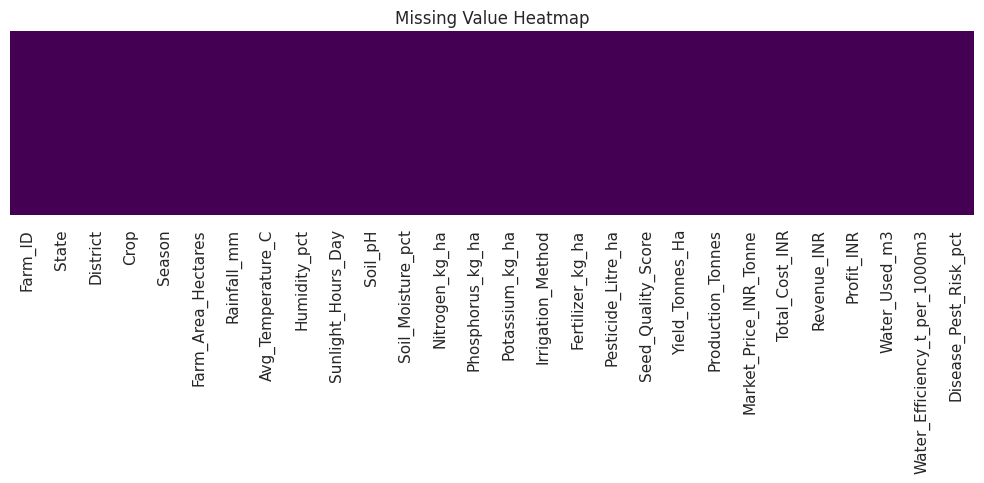

In [24]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Value Heatmap')
plt.tight_layout()
plt.show()

## 7. Data Cleaning and Missing Value Imputation

In [8]:
# Fill numerical missing values with the median
for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

print("Missing values handled successfully")
print("Remaining missing cells:", int(df.isnull().sum().sum()))

Missing values handled successfully
Remaining missing cells: 0


/tmp/ipykernel_1870/306460800.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_plot.index, y=missing_plot["Missing Values"], palette='Reds_r')


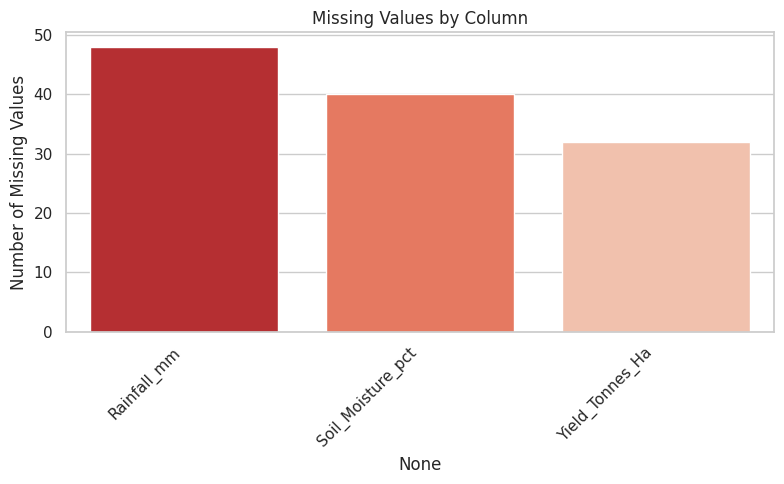

In [26]:
plt.figure(figsize=(8, 5))
missing_plot = missing_summary[missing_summary["Missing Values"] > 0]
if len(missing_plot) > 0:
    sns.barplot(x=missing_plot.index, y=missing_plot["Missing Values"], palette='Reds_r')
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Number of Missing Values")
    plt.title("Missing Values by Column")
    plt.tight_layout()
    plt.show()

**Choosing an appropriate strategy** — possible approaches considered:
- Remove records only when justified (e.g. a handful of rows with many fields missing)
- Fill numerical values using an appropriate statistic when appropriate (mean/median)
- Fill categorical values using a suitable category or method
- Clearly document why the chosen approach is reasonable


Only three numeric columns have missing values, each under 1.2% of rows: `Rainfall_mm`, `Soil_Moisture_pct` and `Yield_Tonnes_Ha`. These are continuous variables that vary strongly by Crop and Season, so the **median of the corresponding Crop+Season group** is used as a more accurate fill value than the single overall column median (with the overall median as a safety-net fallback).

In [27]:
for col in ["Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]:
    df[col] = df.groupby(["Crop", "Season"])[col].transform(lambda x: x.fillna(x.median()))
    df[col] = df[col].fillna(df[col].median())

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


/tmp/ipykernel_1870/3397017635.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[col] = df.groupby(["Crop", "Season"])[col].transform(lambda x: x.fillna(x.median()))
/tmp/ipykernel_1870/3397017635.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[col] = df.groupby(["Crop", "Season"])[col].transform(lambda x: x.fillna(x.median()))
/tmp/ipykernel_1870/3397017635.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
 

## 8. Descriptive Statistics

In [9]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,4000.0,600.922825,287.193381,80.000,371.575,582.0000,831.97500,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,4000.0,26.507150,6.678837,8.000,21.800,26.4000,31.20000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


## 9. Custom Summary: Mean, Median, and Standard Deviation

In [10]:
selected_metrics = ["Yield_Tonnes_Ha", "Production_Tonnes", "Profit_INR", "Water_Used_m3", "Water_Efficiency_t_per_1000m3", "Disease_Pest_Risk_pct"]
custom_summary = df[selected_metrics].agg(["mean", "median", "std"]).T.round(2)
display(custom_summary)

,mean,median,std
Yield_Tonnes_Ha,5.24,1.74,13.31
Production_Tonnes,43.25,11.77,126.88
Profit_INR,111556.46,3673.00,545081.89
Water_Used_m3,6045.57,4435.00,5572.94
Water_Efficiency_t_per_1000m3,5.39,2.94,8.84
Disease_Pest_Risk_pct,46.37,46.40,12.42


In [28]:
stats_df = df[numerical_columns].describe().T
stats_df["range"] = stats_df["max"] - stats_df["min"]
stats_df["IQR"] = stats_df["75%"] - stats_df["25%"]
stats_df.round(2)

,count,mean,std,min,25%,50%,75%,max,range,IQR
Farm_Area_Hectares,4000.0,7.89,4.22,0.50,4.26,7.90,11.65,15.00,14.50,7.39
Rainfall_mm,4000.0,600.92,287.19,80.00,371.58,582.00,831.98,1395.20,1315.20,460.40
Avg_Temperature_C,4000.0,26.82,3.82,16.20,23.90,26.90,29.60,39.70,23.50,5.70
Humidity_pct,4000.0,63.21,11.96,25.00,54.78,63.00,71.90,95.00,70.00,17.13
Sunlight_Hours_Day,4000.0,7.32,1.12,3.50,6.60,7.30,8.10,11.00,7.50,1.50
Soil_pH,4000.0,6.70,0.64,5.20,6.26,6.69,7.14,8.40,3.20,0.88
Soil_Moisture_pct,4000.0,26.51,6.68,8.00,21.80,26.40,31.20,47.00,39.00,9.40
Nitrogen_kg_ha,4000.0,120.25,31.22,40.00,98.50,120.10,141.22,220.00,180.00,42.72
Phosphorus_kg_ha,4000.0,57.78,17.02,15.00,46.20,57.50,69.40,120.00,105.00,23.20
Potassium_kg_ha,4000.0,104.76,27.74,30.00,86.20,105.10,123.60,200.00,170.00,37.40


In [29]:
statistical_summary = pd.DataFrame({
    "Mean": df[numerical_columns].mean(),
    "Median": df[numerical_columns].median(),
    "Std_Dev": df[numerical_columns].std(),
    "Min": df[numerical_columns].min(),
    "Max": df[numerical_columns].max()
}).round(2)
statistical_summary

,Mean,Median,Std_Dev,Min,Max
Farm_Area_Hectares,7.89,7.90,4.22,0.50,15.00
Rainfall_mm,600.92,582.00,287.19,80.00,1395.20
Avg_Temperature_C,26.82,26.90,3.82,16.20,39.70
Humidity_pct,63.21,63.00,11.96,25.00,95.00
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00
Soil_pH,6.70,6.69,0.64,5.20,8.40
Soil_Moisture_pct,26.51,26.40,6.68,8.00,47.00
Nitrogen_kg_ha,120.25,120.10,31.22,40.00,220.00
Phosphorus_kg_ha,57.78,57.50,17.02,15.00,120.00
Potassium_kg_ha,104.76,105.10,27.74,30.00,200.00


In [30]:
season_summary = df.groupby("Season")[numerical_columns].agg(["mean", "median", "std"]).round(2)
season_summary

/tmp/ipykernel_1870/3211082275.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  season_summary = df.groupby("Season")[numerical_columns].agg(["mean", "median", "std"]).round(2)


Farm_Area_Hectares              Rainfall_mm                 \
                     mean median   std        mean median     std   
Season                                                              
Kharif               7.94   8.18  4.28      849.20  853.1  183.69   
Rabi                 7.75   7.68  4.18      437.62  432.2  175.35   
Zaid                 8.09   8.09  4.16      304.65  288.2  157.24   

       Avg_Temperature_C              Humidity_pct  ... Profit_INR  \
                    mean median   std         mean  ...        std   
Season                                              ...              
Kharif             28.45   28.5  2.51        71.81  ...  611549.78   
Rabi               23.49   23.5  2.46        57.89  ...  489901.25   
Zaid               31.04   31.0  2.55        52.01  ...  436356.75   

       Water_Used_m3                  Water_Efficiency_t_per_1000m3         \
                mean  median      std                          mean median   
Season                                                                       
Kharif       6102.20  4469.0  5670.58                          5.89   3.28   
Rabi         5846.99  4292.0  5397.65                          5.19   2.74   
Zaid         6419.89  4805.0  5734.62                          4.41   2.30   

             Disease_Pest_Risk_pct                
         std                  mean median    std  
Season                                            
Kharif  9.83                 54.47   54.5  10.09  
Rabi    8.26                 40.48   40.6  10.10  
Zaid    6.93                 38.22   37.9   9.87  

[3 rows x 66 columns]

## 10. Distribution of Records by Season

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


/tmp/ipykernel_1870/426210686.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Season", order=["Kharif", "Rabi", "Zaid"], palette="Set2")


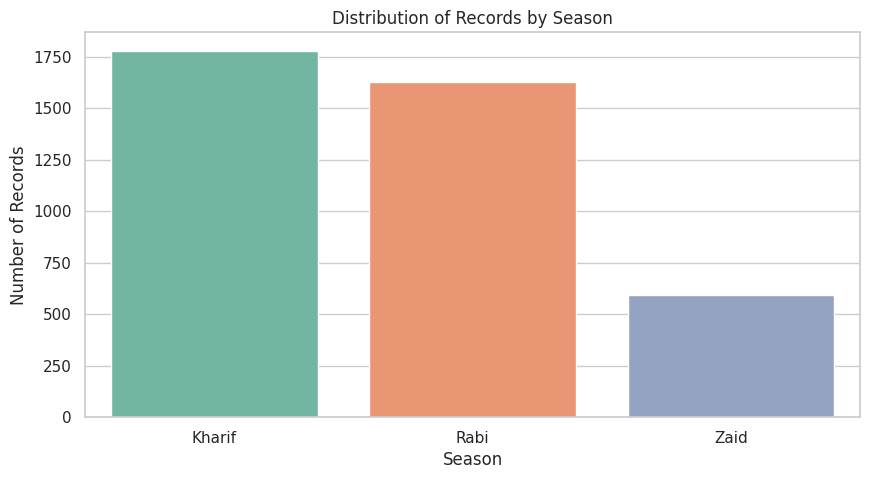

In [11]:
print(df["Season"].value_counts())
sns.countplot(data=df, x="Season", order=["Kharif", "Rabi", "Zaid"], palette="Set2")
plt.title("Distribution of Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.show()

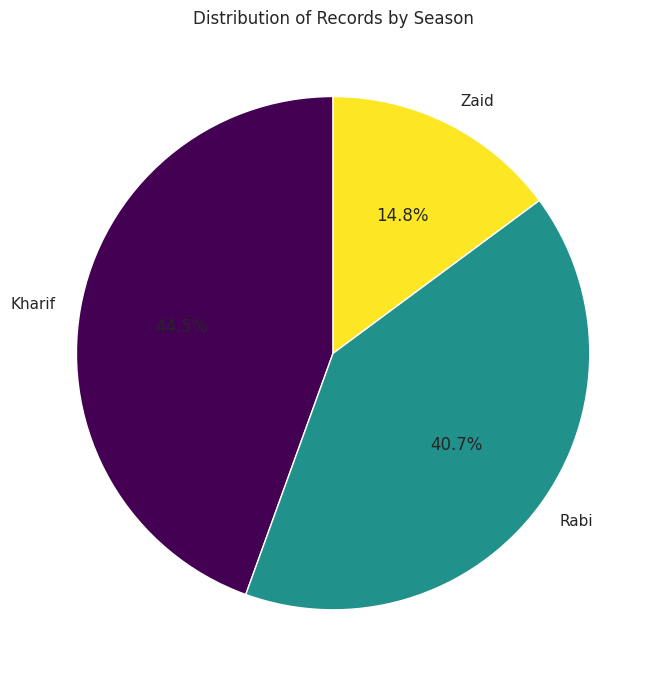

In [31]:
# Univariate: Season distribution (pie chart)
plt.figure(figsize=(7, 7))
df["Season"].value_counts().plot.pie(autopct="%1.1f%%", startangle=90, cmap="viridis")
plt.title("Distribution of Records by Season")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 11. Distribution of Crops

/tmp/ipykernel_1870/1339187944.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y="Crop", order=df["Crop"].value_counts().index, palette="viridis")


Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64


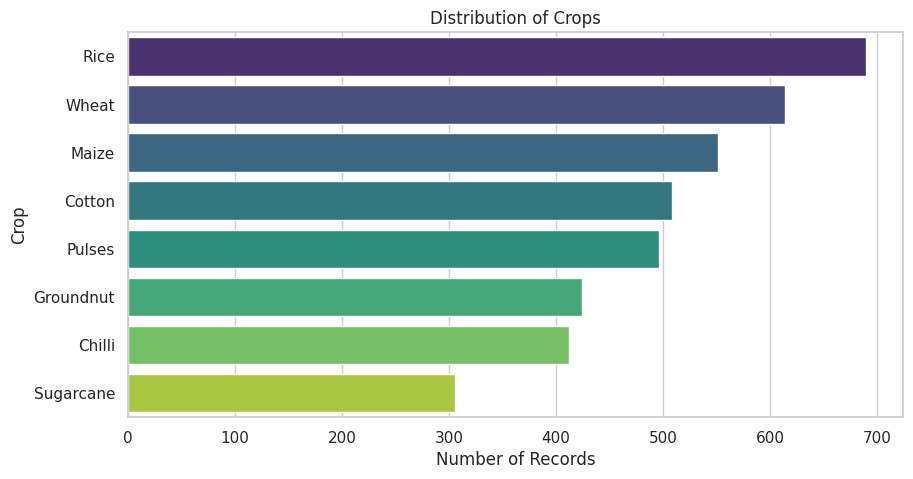

In [12]:
print(df["Crop"].value_counts())
sns.countplot(data=df, y="Crop", order=df["Crop"].value_counts().index, palette="viridis")
plt.title("Distribution of Crops")
plt.xlabel("Number of Records")
plt.ylabel("Crop")
plt.show()

/tmp/ipykernel_1870/1094533361.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Irrigation_Method", order=df["Irrigation_Method"].value_counts().index, ax=axes[0], palette="Set3")
/tmp/ipykernel_1870/1094533361.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y="State", order=df["State"].value_counts().index, ax=axes[1], palette="Set3")


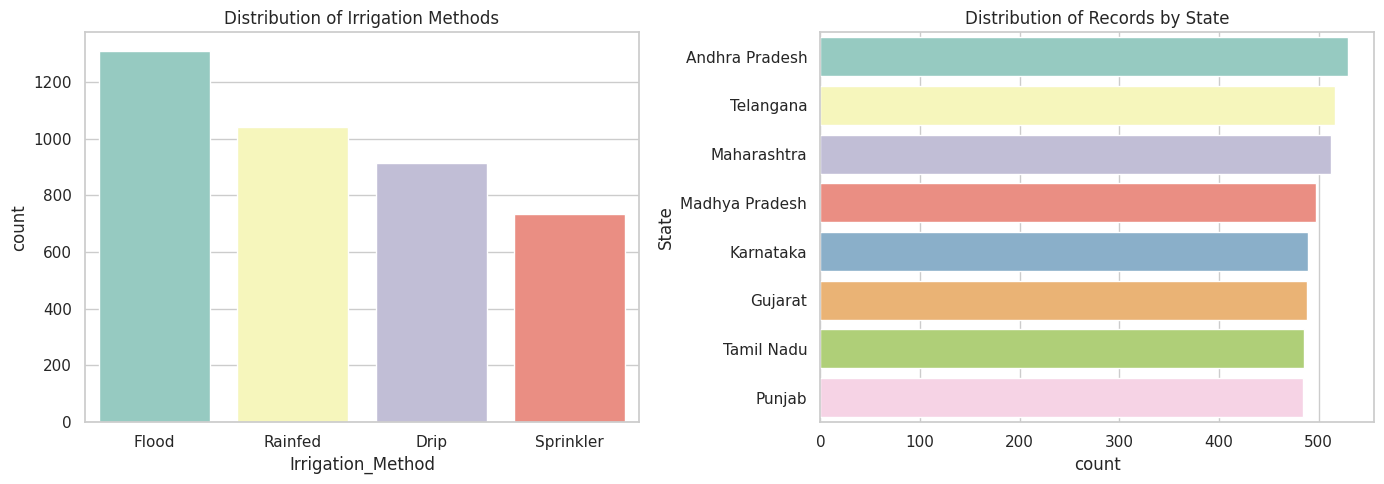

In [32]:
# Univariate: Irrigation method & State distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x="Irrigation_Method", order=df["Irrigation_Method"].value_counts().index, ax=axes[0], palette="Set3")
axes[0].set_title("Distribution of Irrigation Methods")
sns.countplot(data=df, y="State", order=df["State"].value_counts().index, ax=axes[1], palette="Set3")
axes[1].set_title("Distribution of Records by State")
plt.tight_layout()
plt.show()

## 12. Univariate Analysis: Numerical Distributions

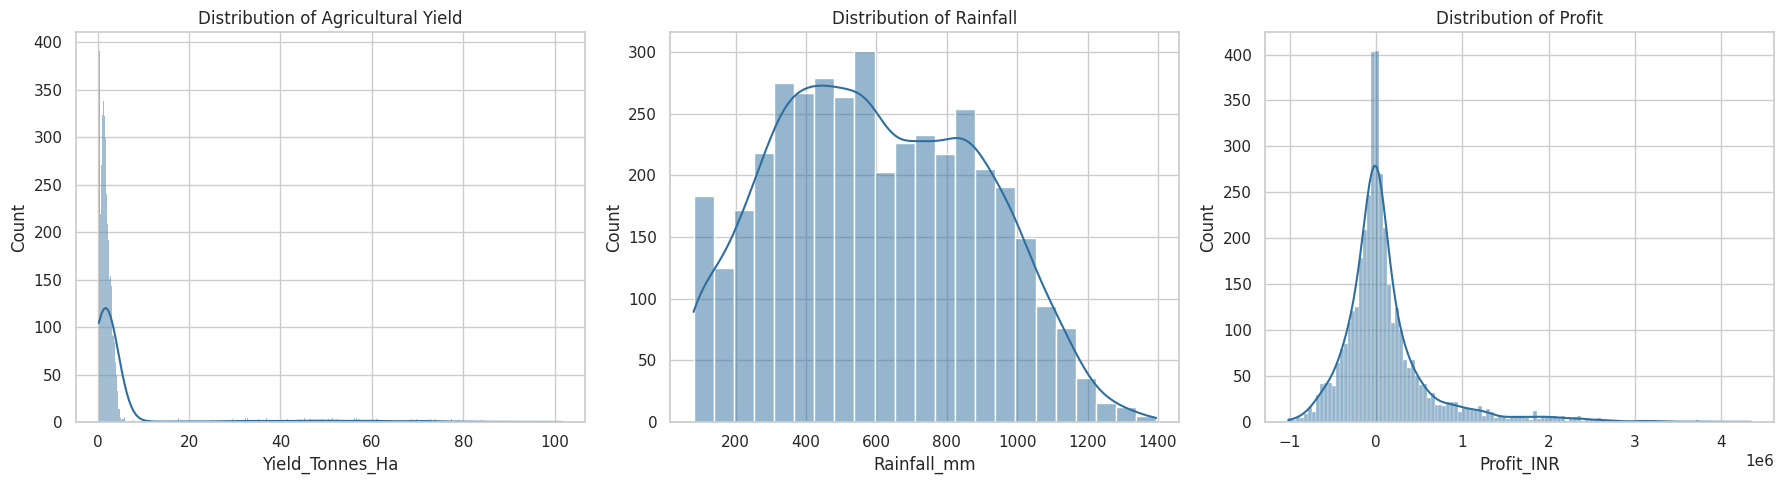

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, column, title in zip(axes, ["Yield_Tonnes_Ha", "Rainfall_mm", "Profit_INR"], ["Distribution of Agricultural Yield", "Distribution of Rainfall", "Distribution of Profit"]):
    sns.histplot(df[column], kde=True, ax=ax, color="#2f6f9f")
    ax.set_title(title)
plt.tight_layout()
plt.show()

## 13. Outlier Analysis Using Box Plots

In [34]:
outlier_cols = ["Yield_Tonnes_Ha", "Profit_INR", "Water_Used_m3", "Rainfall_mm", "Fertilizer_kg_ha", "Disease_Pest_Risk_pct"]

outlier_summary = []
for col in outlier_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append([col, round(lower, 2), round(upper, 2), n_out, round(100 * n_out / len(df), 2)])

outlier_df = pd.DataFrame(outlier_summary, columns=["Column", "Lower_Bound", "Upper_Bound", "Outlier_Count", "Outlier_%"])
outlier_df

,Column,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_%
0,Yield_Tonnes_Ha,-1.62,5.50,302,7.55
1,Profit_INR,-696111.00,763567.00,404,10.10
2,Water_Used_m3,-6072.75,16171.25,276,6.90
3,Rainfall_mm,-319.02,1522.57,0,0.00
4,Fertilizer_kg_ha,19.14,352.04,15,0.38
5,Disease_Pest_Risk_pct,10.90,81.30,10,0.25


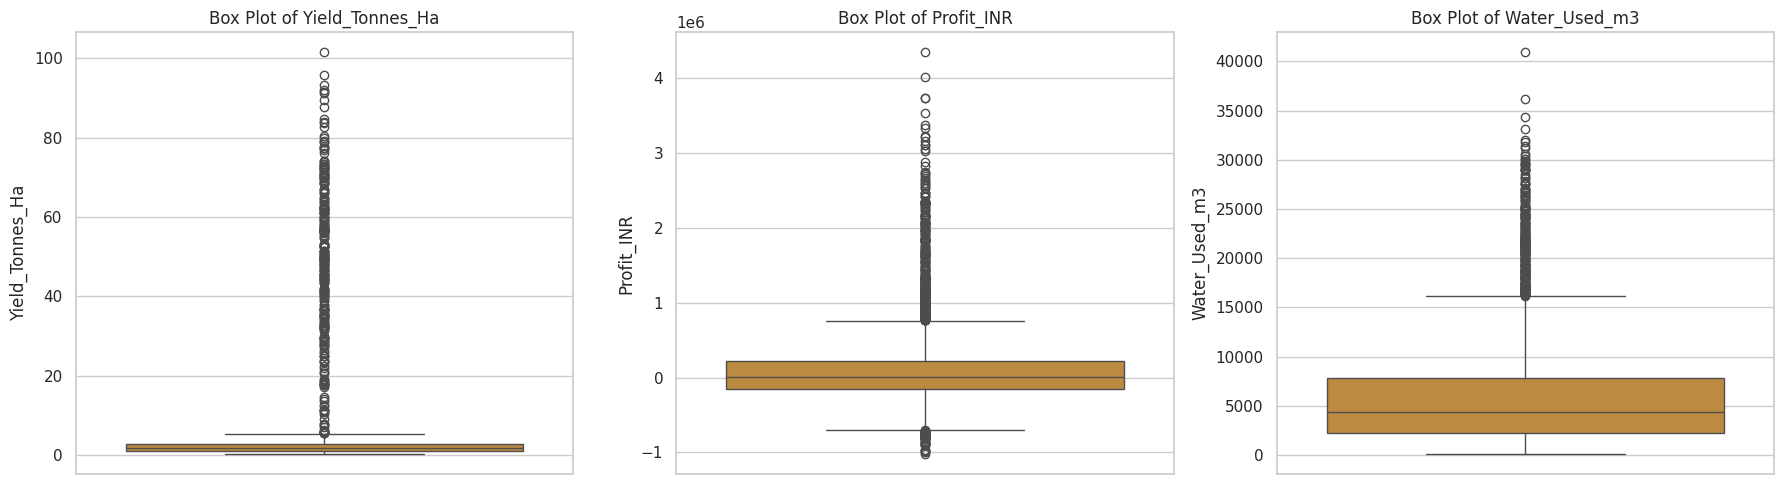

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, column in zip(axes, ["Yield_Tonnes_Ha", "Profit_INR", "Water_Used_m3"]):
    sns.boxplot(y=df[column], ax=ax, color="#d28e2d")
    ax.set_title(f"Box Plot of {column}")
plt.tight_layout()
plt.show()

## 14. Seasonal Performance Analysis

In [15]:
season_order = ["Kharif", "Rabi", "Zaid"]
df["Season"] = pd.Categorical(df["Season"], categories=season_order, ordered=True)
season_summary = df.groupby("Season", observed=False)[["Yield_Tonnes_Ha", "Profit_INR", "Water_Used_m3", "Water_Efficiency_t_per_1000m3", "Disease_Pest_Risk_pct"]].agg(["mean", "median", "std"]).round(2)
display(season_summary)

Yield_Tonnes_Ha               Profit_INR                      \
                  mean median    std       mean   median        std   
Season                                                                
Kharif            5.63   1.94  14.39  178914.65  38808.0  611549.78   
Rabi              5.04   1.67  12.75   87689.47  -3187.0  489901.25   
Zaid              4.64   1.46  11.27  -24804.82 -62144.0  436356.75   

       Water_Used_m3                  Water_Efficiency_t_per_1000m3         \
                mean  median      std                          mean median   
Season                                                                       
Kharif       6102.20  4469.0  5670.58                          5.89   3.28   
Rabi         5846.99  4292.0  5397.65                          5.19   2.74   
Zaid         6419.89  4805.0  5734.62                          4.41   2.30   

             Disease_Pest_Risk_pct                
         std                  mean median    std  
Season                                            
Kharif  9.83                 54.47   54.5  10.09  
Rabi    8.26                 40.48   40.6  10.10  
Zaid    6.93                 38.22   37.9   9.87

/tmp/ipykernel_1870/2806217588.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha", palette="coolwarm")


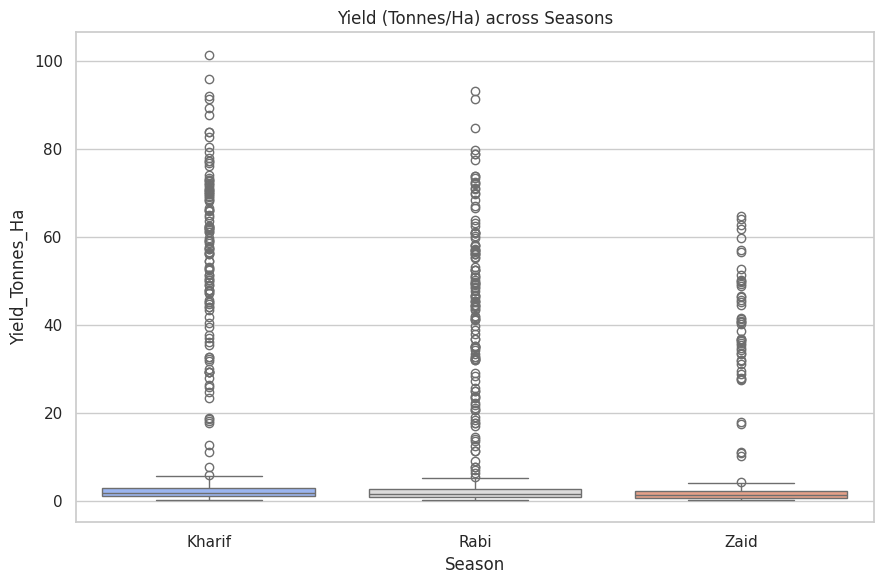

In [35]:
plt.figure(figsize=(9, 6))
sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha", palette="coolwarm")
plt.title("Yield (Tonnes/Ha) across Seasons")
plt.tight_layout()
plt.show()

## 15. Seasonal Comparison Charts

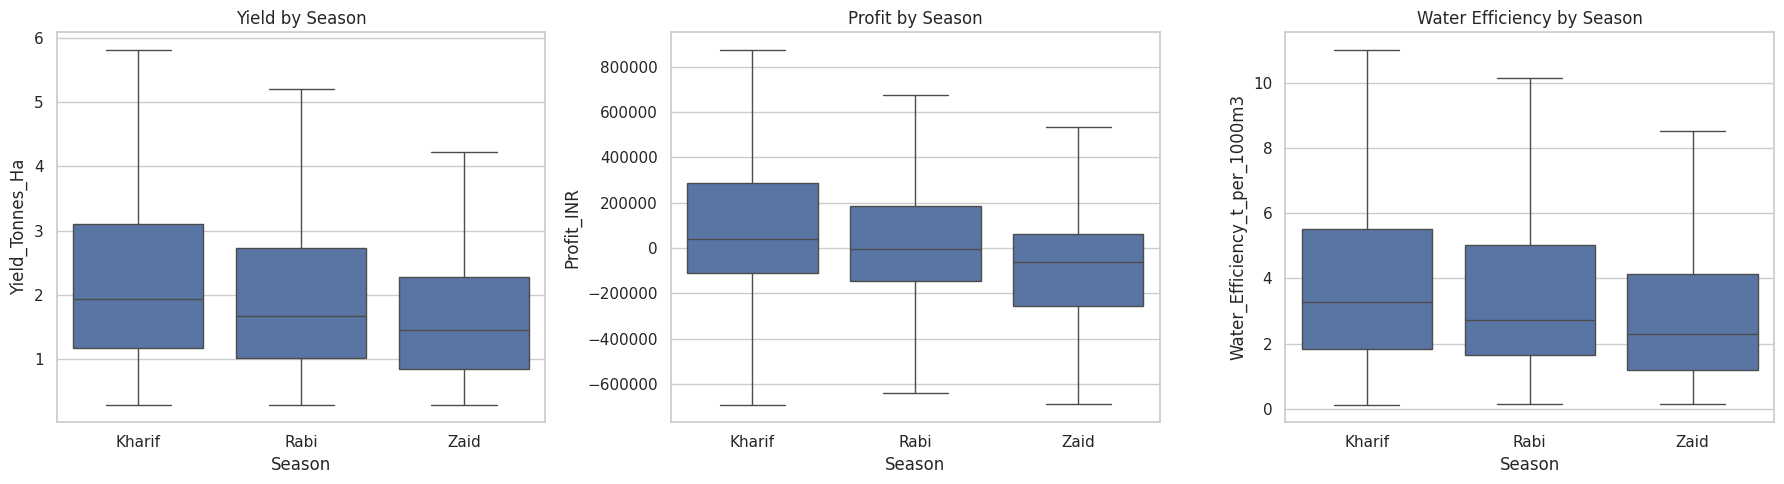

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, column, title in zip(axes, ["Yield_Tonnes_Ha", "Profit_INR", "Water_Efficiency_t_per_1000m3"], ["Yield by Season", "Profit by Season", "Water Efficiency by Season"]):
    sns.boxplot(data=df, x="Season", y=column, order=season_order, ax=ax, showfliers=False)
    ax.set_title(title)
plt.tight_layout()
plt.show()

In [43]:
season_metrics = df.groupby("Season")[["Yield_Tonnes_Ha", "Profit_INR", "Total_Cost_INR", "Revenue_INR",
                                        "Water_Efficiency_t_per_1000m3", "Disease_Pest_Risk_pct", "Rainfall_mm"]].mean().round(2)
season_metrics

/tmp/ipykernel_1870/4146772684.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  season_metrics = df.groupby("Season")[["Yield_Tonnes_Ha", "Profit_INR", "Total_Cost_INR", "Revenue_INR",


,Yield_Tonnes_Ha,Profit_INR,Total_Cost_INR,Revenue_INR,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Rainfall_mm
Season,,,,,,,
Kharif,5.63,178914.65,531804.41,710719.06,5.89,54.47,849.20
Rabi,5.04,87689.47,513836.58,601526.05,5.19,40.48,437.62
Zaid,4.64,-24804.82,543976.73,519171.90,4.41,38.22,304.65


## 16. Seasonal Analysis by Crop

,Season,Crop,Records,Mean_Yield,Mean_Profit
0,Kharif,Chilli,185,1.73,954380.42
1,Kharif,Cotton,215,1.37,216999.55
2,Kharif,Groundnut,193,1.48,108265.44
3,Kharif,Maize,234,2.97,-39332.67
4,Kharif,Pulses,221,1.04,43338.90
5,Kharif,Rice,314,2.70,-64903.40
6,Kharif,Sugarcane,125,53.46,1000790.81
7,Kharif,Wheat,292,2.25,-105871.87
8,Rabi,Chilli,163,1.47,638572.50
9,Rabi,Cotton,201,1.20,107343.59


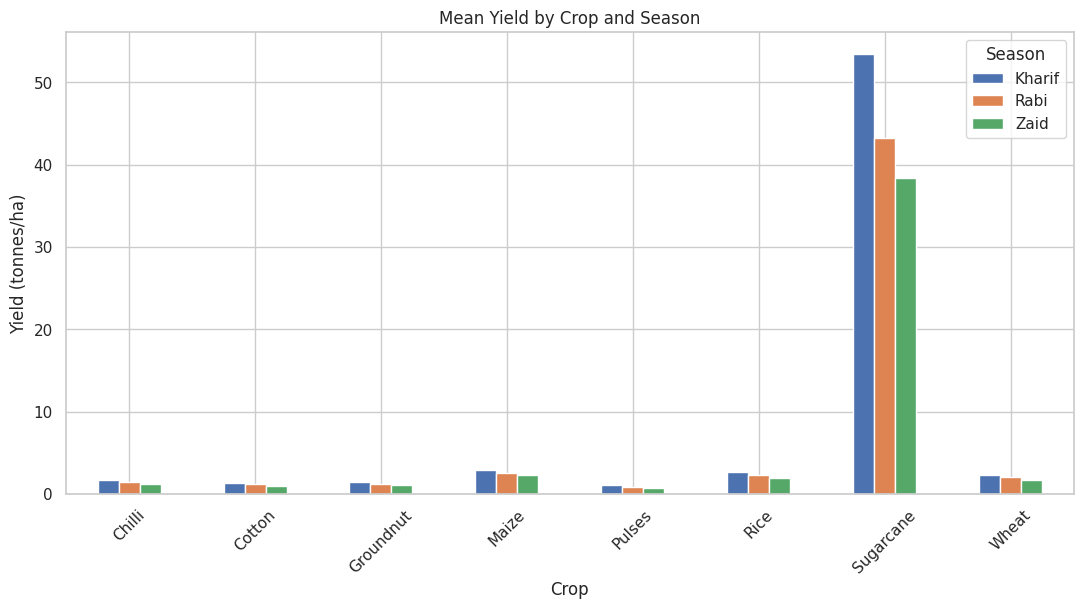

In [17]:
crop_season_summary = df.groupby(["Season", "Crop"], observed=False).agg(
    Records=("Farm_ID", "size"),
    Mean_Yield=("Yield_Tonnes_Ha", "mean"),
    Mean_Profit=("Profit_INR", "mean")
).reset_index().round(2)
display(crop_season_summary)

pivot = crop_season_summary.pivot(index="Crop", columns="Season", values="Mean_Yield").reindex(columns=season_order)
pivot.plot(kind="bar", figsize=(13, 6))
plt.title("Mean Yield by Crop and Season")
plt.ylabel("Yield (tonnes/ha)")
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_1870/3811501125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Season", y=m, ax=ax, estimator=np.mean, errorbar="sd", palette="Set2")
/tmp/ipykernel_1870/3811501125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Season", y=m, ax=ax, estimator=np.mean, errorbar="sd", palette="Set2")
/tmp/ipykernel_1870/3811501125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Season", y=m, ax=ax, estimator=np.mean, errorbar="sd", palette="Set2")
/tmp/ipykernel_1870/3811501125.py:4: FutureWarnin

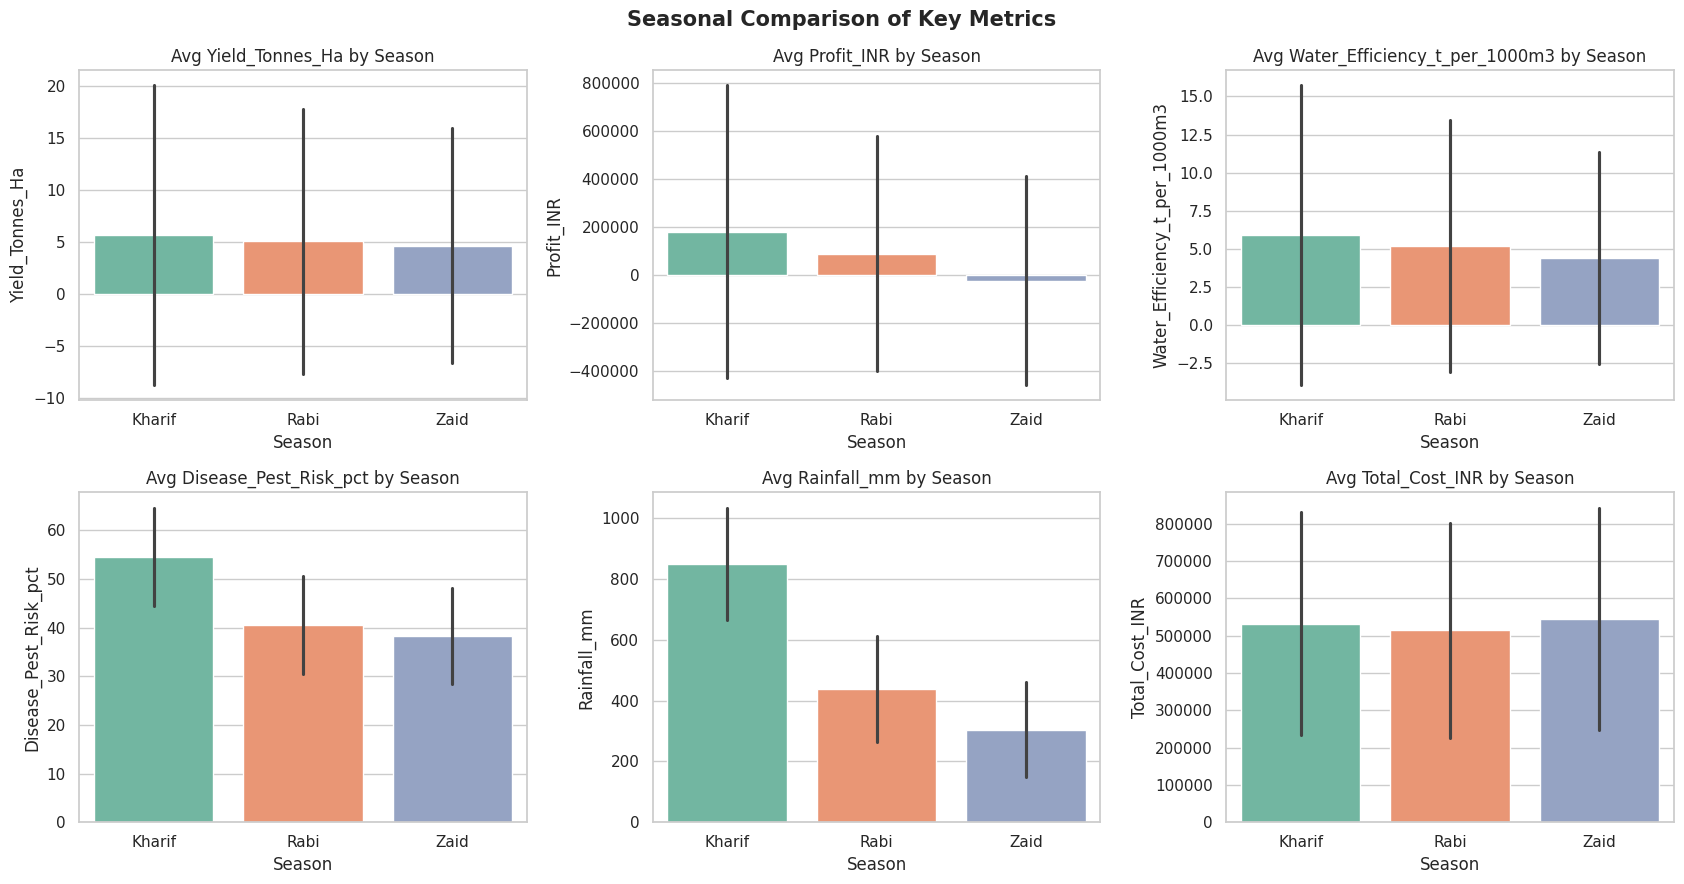

In [44]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
metrics = ["Yield_Tonnes_Ha", "Profit_INR", "Water_Efficiency_t_per_1000m3", "Disease_Pest_Risk_pct", "Rainfall_mm", "Total_Cost_INR"]
for ax, m in zip(axes.flatten(), metrics):
    sns.barplot(data=df, x="Season", y=m, ax=ax, estimator=np.mean, errorbar="sd", palette="Set2")
    ax.set_title(f"Avg {m} by Season")
plt.suptitle("Seasonal Comparison of Key Metrics", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

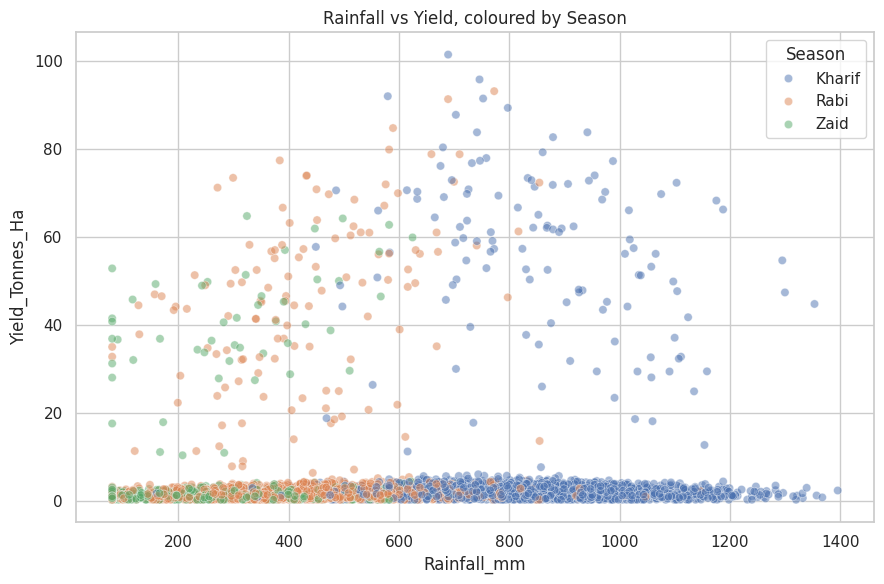

In [36]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", hue="Season", alpha=0.5)
plt.title("Rainfall vs Yield, coloured by Season")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1870/1251160366.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Irrigation_Method", y="Profit_INR", palette="Set3")


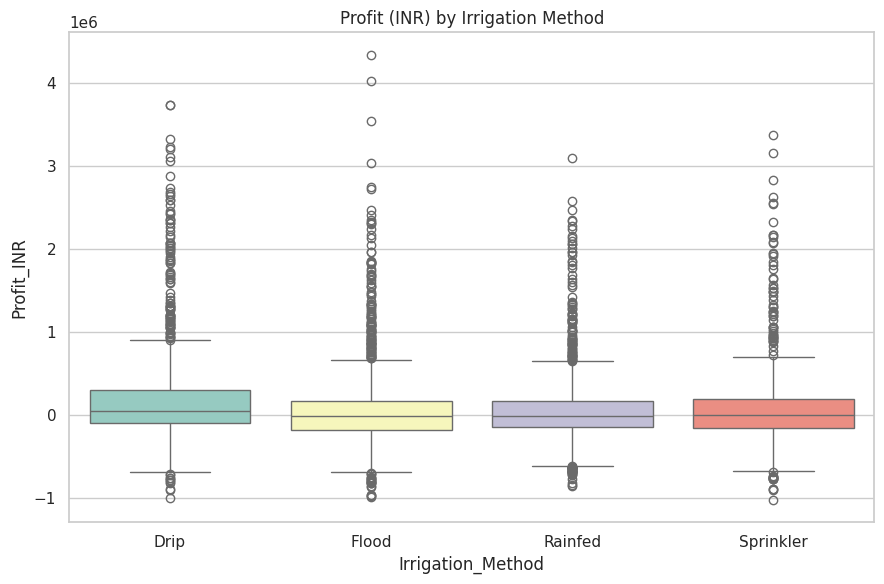

In [37]:
plt.figure(figsize=(9, 6))
sns.boxplot(data=df, x="Irrigation_Method", y="Profit_INR", palette="Set3")
plt.title("Profit (INR) by Irrigation Method")
plt.tight_layout()
plt.show()

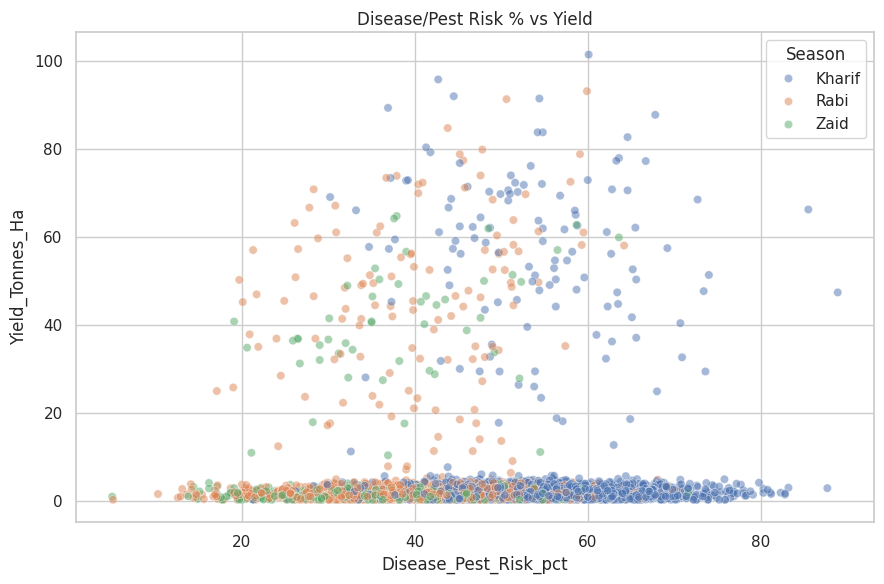

In [38]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="Disease_Pest_Risk_pct", y="Yield_Tonnes_Ha", hue="Season", alpha=0.5)
plt.title("Disease/Pest Risk % vs Yield")
plt.tight_layout()
plt.show()

## 17. Correlation Analysis

,Rainfall_mm,Avg_Temperature_C,Soil_Moisture_pct,Fertilizer_kg_ha,Seed_Quality_Score,Water_Used_m3,Disease_Pest_Risk_pct,Yield_Tonnes_Ha,Profit_INR
Rainfall_mm,1.00,0.20,0.51,0.02,-0.02,0.00,0.62,0.03,0.11
Avg_Temperature_C,0.20,1.00,0.08,0.02,-0.03,0.02,0.25,0.01,0.01
Soil_Moisture_pct,0.51,0.08,1.00,0.01,-0.02,0.00,0.38,0.01,0.09
Fertilizer_kg_ha,0.02,0.02,0.01,1.00,0.02,0.00,0.02,0.00,-0.07
Seed_Quality_Score,-0.02,-0.03,-0.02,0.02,1.00,0.02,-0.02,-0.01,0.01
Water_Used_m3,0.00,0.02,0.00,0.00,0.02,1.00,0.01,0.39,0.19
Disease_Pest_Risk_pct,0.62,0.25,0.38,0.02,-0.02,0.01,1.00,0.01,0.07
Yield_Tonnes_Ha,0.03,0.01,0.01,0.00,-0.01,0.39,0.01,1.00,0.49
Profit_INR,0.11,0.01,0.09,-0.07,0.01,0.19,0.07,0.49,1.00


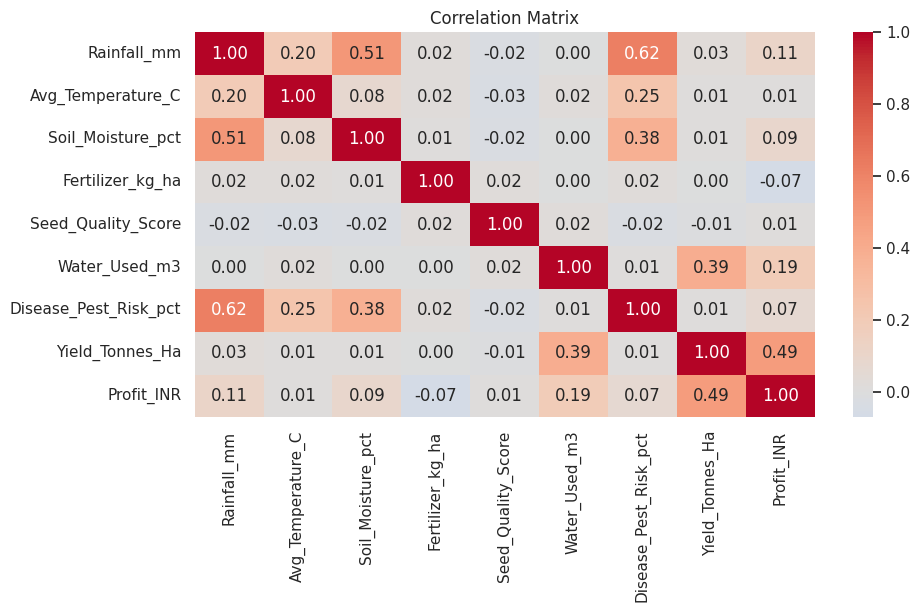

In [18]:
correlation_columns = ["Rainfall_mm", "Avg_Temperature_C", "Soil_Moisture_pct", "Fertilizer_kg_ha", "Seed_Quality_Score", "Water_Used_m3", "Disease_Pest_Risk_pct", "Yield_Tonnes_Ha", "Profit_INR"]
corr = df[correlation_columns].corr().round(2)
display(corr)
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [42]:
print("Top correlations with Yield_Tonnes_Ha:")
print(corr["Yield_Tonnes_Ha"].sort_values(ascending=False).drop("Yield_Tonnes_Ha").head(5))
print("...")
print(corr["Yield_Tonnes_Ha"].sort_values(ascending=False).drop("Yield_Tonnes_Ha").tail(5))

print("\nTop correlations with Profit_INR:")
print(corr["Profit_INR"].sort_values(ascending=False).drop("Profit_INR").head(5))
print("...")
print(corr["Profit_INR"].sort_values(ascending=False).drop("Profit_INR").tail(5))

Top correlations with Yield_Tonnes_Ha:
Profit_INR           0.49
Water_Used_m3        0.39
Rainfall_mm          0.03
Avg_Temperature_C    0.01
Soil_Moisture_pct    0.01
Name: Yield_Tonnes_Ha, dtype: float64
...
Avg_Temperature_C        0.01
Soil_Moisture_pct        0.01
Disease_Pest_Risk_pct    0.01
Fertilizer_kg_ha         0.00
Seed_Quality_Score      -0.01
Name: Yield_Tonnes_Ha, dtype: float64

Top correlations with Profit_INR:
Yield_Tonnes_Ha          0.49
Water_Used_m3            0.19
Rainfall_mm              0.11
Soil_Moisture_pct        0.09
Disease_Pest_Risk_pct    0.07
Name: Profit_INR, dtype: float64
...
Soil_Moisture_pct        0.09
Disease_Pest_Risk_pct    0.07
Avg_Temperature_C        0.01
Seed_Quality_Score       0.01
Fertilizer_kg_ha        -0.07
Name: Profit_INR, dtype: float64


##  Multivariate Analysis

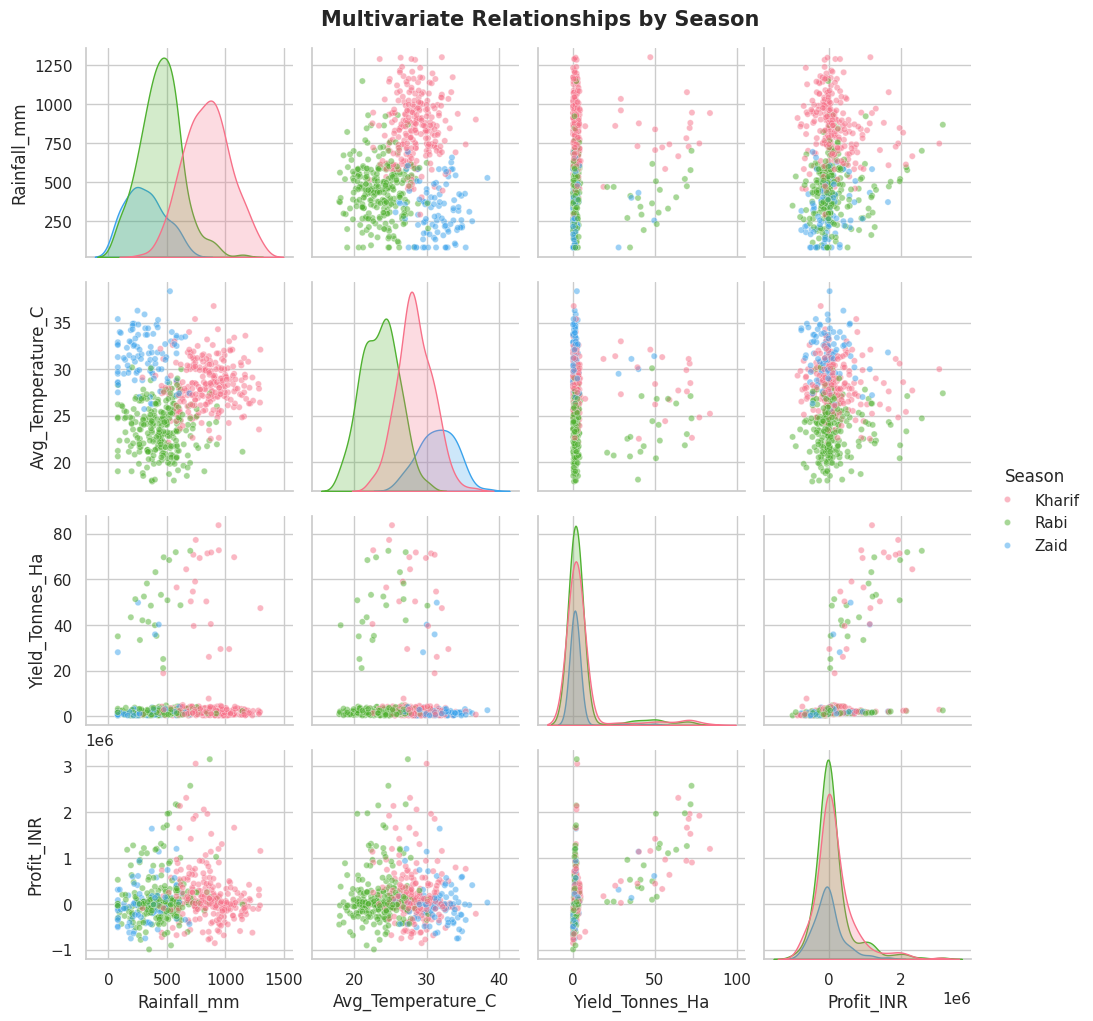

In [39]:
pair_cols = ["Rainfall_mm", "Avg_Temperature_C", "Yield_Tonnes_Ha", "Profit_INR", "Season"]
sample_df = df[pair_cols].sample(600, random_state=42)  # sampled for readable rendering
sns.pairplot(sample_df, hue="Season", diag_kind="kde", palette="husl", plot_kws={"alpha": 0.5, "s": 20})
plt.suptitle("Multivariate Relationships by Season", y=1.02, fontsize=15, fontweight="bold")
plt.show()

/tmp/ipykernel_1870/4117852025.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_yield = df.pivot_table(values="Yield_Tonnes_Ha", index="Crop", columns="Season", aggfunc="mean")


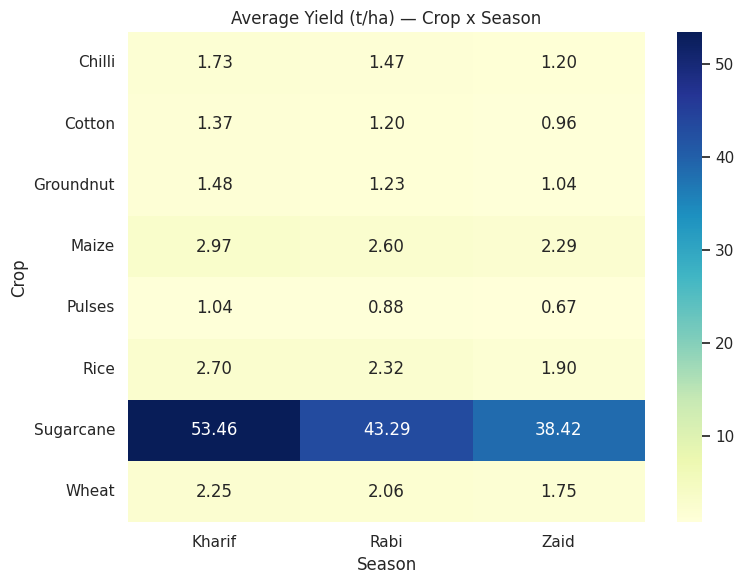

In [40]:
pivot_yield = df.pivot_table(values="Yield_Tonnes_Ha", index="Crop", columns="Season", aggfunc="mean")
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_yield, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Average Yield (t/ha) — Crop x Season")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1870/4036235826.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_profit = df.pivot_table(values="Profit_INR", index="State", columns="Season", aggfunc="mean")


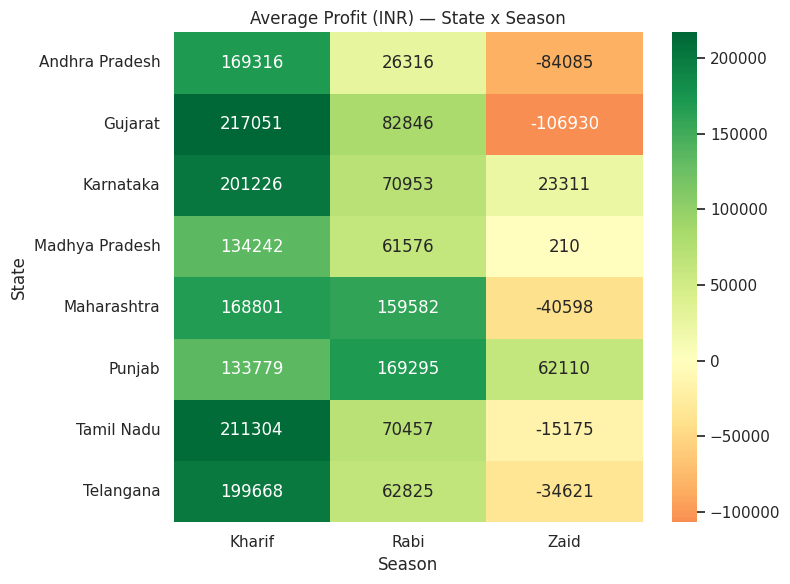

In [41]:
pivot_profit = df.pivot_table(values="Profit_INR", index="State", columns="Season", aggfunc="mean")
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_profit, annot=True, fmt=".0f", cmap="RdYlGn", center=0)
plt.title("Average Profit (INR) — State x Season")
plt.tight_layout()
plt.show()

## 18. Student-Designed Analyses

Four focused questions were designed independently to dig deeper into seasonal agricultural performance, beyond the standard EDA above.

### Analysis 1: Which irrigation method is most water-efficient, and does this hold across all seasons?

In [45]:
irr_season = df.groupby(["Season", "Irrigation_Method"])["Water_Efficiency_t_per_1000m3"].mean().unstack().round(3)
irr_season

/tmp/ipykernel_1870/1288487604.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  irr_season = df.groupby(["Season", "Irrigation_Method"])["Water_Efficiency_t_per_1000m3"].mean().unstack().round(3)


Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,6.804,3.637,8.848,4.622
Rabi,6.047,3.478,6.873,4.644
Zaid,5.296,2.730,5.479,4.860


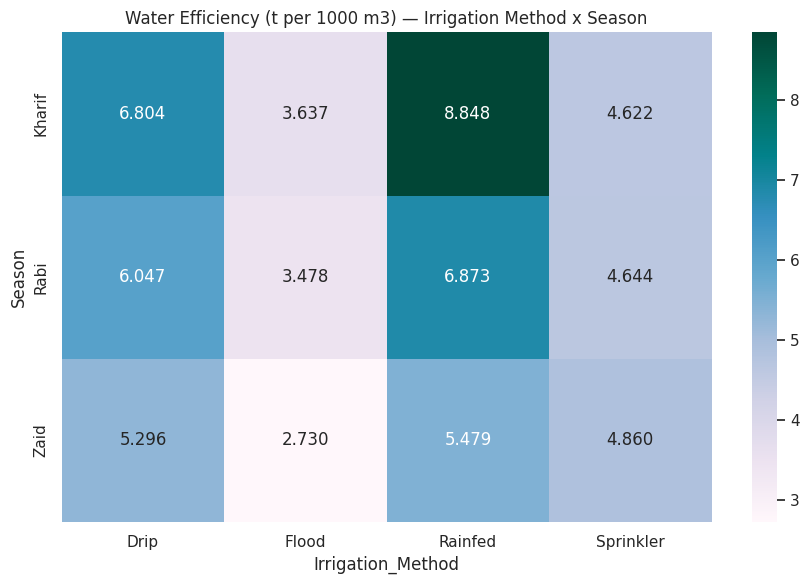

In [46]:
plt.figure(figsize=(9, 6))
sns.heatmap(irr_season, annot=True, fmt=".3f", cmap="PuBuGn")
plt.title("Water Efficiency (t per 1000 m3) — Irrigation Method x Season")
plt.tight_layout()
plt.show()

### Analysis 2: Which crop-season combination is the most profitable per hectare?

In [47]:
df["Profit_per_Ha"] = df["Profit_INR"] / df["Farm_Area_Hectares"]
profit_crop_season = df.groupby(["Crop", "Season"])["Profit_per_Ha"].mean().unstack().round(0)
profit_crop_season

/tmp/ipykernel_1870/3774870489.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  profit_crop_season = df.groupby(["Crop", "Season"])["Profit_per_Ha"].mean().unstack().round(0)


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,111812.0,85696.0,51578.0
Cotton,27343.0,13518.0,-3129.0
Groundnut,16871.0,1927.0,-8168.0
Maize,-4968.0,-11776.0,-20422.0
Pulses,7044.0,-3420.0,-18905.0
Rice,-7987.0,-14525.0,-25266.0
Sugarcane,120564.0,86013.0,68050.0
Wheat,-13182.0,-16084.0,-25223.0


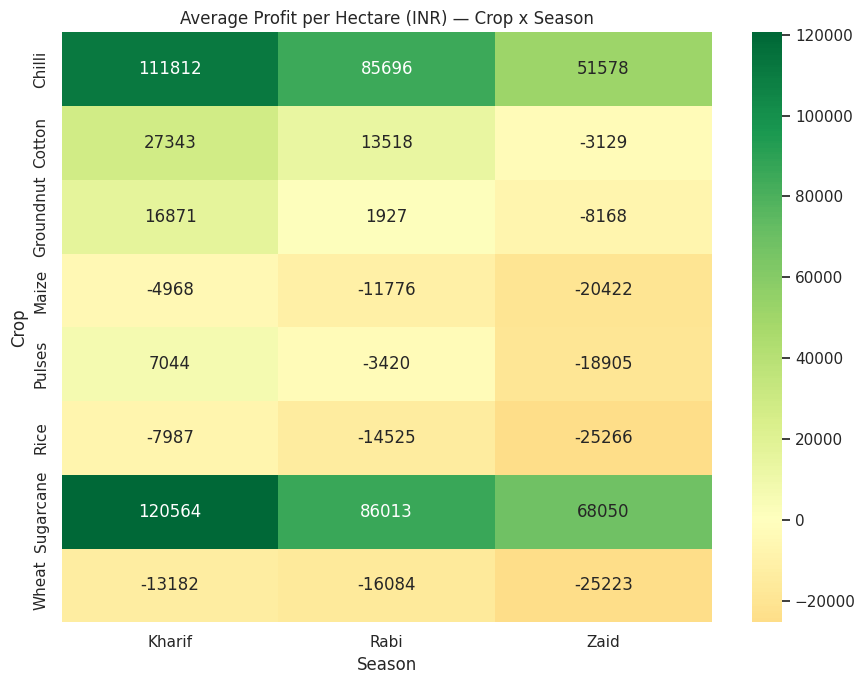

In [48]:
plt.figure(figsize=(9, 7))
sns.heatmap(profit_crop_season, annot=True, fmt=".0f", cmap="RdYlGn", center=0)
plt.title("Average Profit per Hectare (INR) — Crop x Season")
plt.tight_layout()
plt.show()

### Analysis 3: How does disease/pest risk relate to yield loss, and does this vary by season?

In [49]:
df["Risk_Band"] = pd.cut(df["Disease_Pest_Risk_pct"], bins=[0, 25, 50, 75, 100],
                          labels=["Low(0-25)", "Moderate(25-50)", "High(50-75)", "Very High(75-100)"])
risk_yield = df.groupby(["Risk_Band", "Season"], observed=True)["Yield_Tonnes_Ha"].mean().unstack().round(2)
risk_yield

Season,Kharif,Rabi,Zaid
Risk_Band,,,
Low(0-25),0.30,5.85,3.07
Moderate(25-50),6.21,4.79,4.60
High(50-75),5.35,5.81,6.14
Very High(75-100),5.07,NaN,NaN


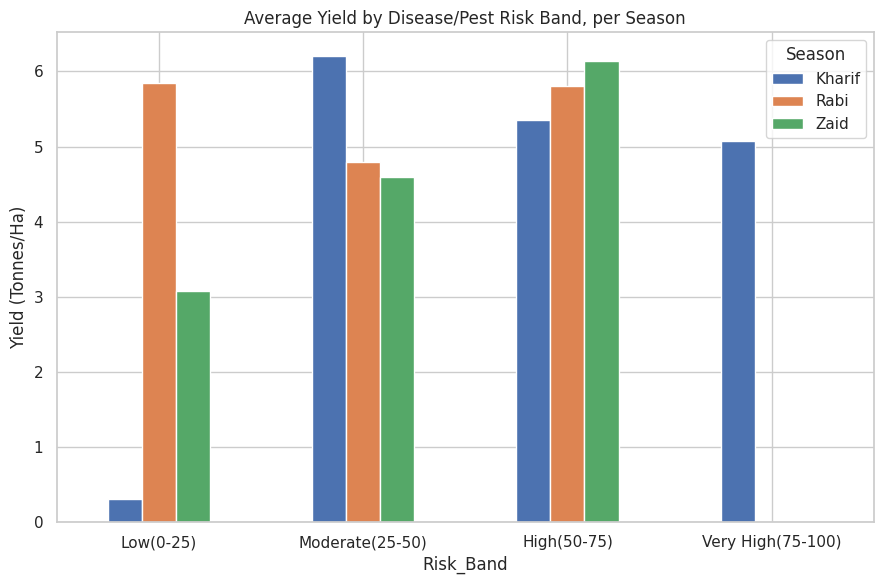

In [50]:
plt.figure(figsize=(9, 6))
risk_yield.plot(kind="bar", ax=plt.gca())
plt.title("Average Yield by Disease/Pest Risk Band, per Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 19. Consolidating the Evidence

Recomputing the key headline numbers referenced in the Insights section below, so every claim is directly traceable to the dataset.

In [52]:
best_season_yield = season_metrics["Yield_Tonnes_Ha"].idxmax()
worst_season_yield = season_metrics["Yield_Tonnes_Ha"].idxmin()
best_season_profit = season_metrics["Profit_INR"].idxmax()
worst_season_profit = season_metrics["Profit_INR"].idxmin()
best_irrigation_overall = df.groupby("Irrigation_Method")["Water_Efficiency_t_per_1000m3"].mean().idxmax()
worst_irrigation_overall = df.groupby("Irrigation_Method")["Water_Efficiency_t_per_1000m3"].mean().idxmin()
best_crop_season = profit_crop_season.stack().idxmax()
worst_crop_season = profit_crop_season.stack().idxmin()
loss_making_pct = (df["Profit_INR"] < 0).mean() * 100
corr_rainfall_yield = corr.loc["Rainfall_mm", "Yield_Tonnes_Ha"]
corr_risk_yield = corr.loc["Disease_Pest_Risk_pct", "Yield_Tonnes_Ha"]
corr_fert_yield = corr.loc["Fertilizer_kg_ha", "Yield_Tonnes_Ha"]

df["Revenue_per_Cost"] = df["Revenue_INR"] / df["Total_Cost_INR"]
best_state_overall = df.groupby("State")["Revenue_per_Cost"].mean().idxmax()
worst_state_overall = df.groupby("State")["Revenue_per_Cost"].mean().idxmin()

print(f"Best season for yield: {best_season_yield} ({season_metrics.loc[best_season_yield,'Yield_Tonnes_Ha']} t/ha)")
print(f"Worst season for yield: {worst_season_yield} ({season_metrics.loc[worst_season_yield,'Yield_Tonnes_Ha']} t/ha)")
print(f"Best season for profit: {best_season_profit} (avg INR {season_metrics.loc[best_season_profit,'Profit_INR']:.0f})")
print(f"Worst season for profit: {worst_season_profit} (avg INR {season_metrics.loc[worst_season_profit,'Profit_INR']:.0f})")
print(f"Most water-efficient irrigation: {best_irrigation_overall}")
print(f"Least water-efficient irrigation: {worst_irrigation_overall}")
print(f"Most profitable crop-season combo (per ha): {best_crop_season}")
print(f"Least profitable crop-season combo (per ha): {worst_crop_season}")
print(f"% of farms operating at a loss: {loss_making_pct:.1f}%")
print(f"Correlation Rainfall vs Yield: {corr_rainfall_yield:.3f}")
print(f"Correlation Disease/Pest Risk vs Yield: {corr_risk_yield:.3f}")
print(f"Correlation Fertilizer vs Yield: {corr_fert_yield:.3f}")
print(f"Best state (Revenue/Cost): {best_state_overall}")
print(f"Weakest state (Revenue/Cost): {worst_state_overall}")

Best season for yield: Kharif (5.63 t/ha)
Worst season for yield: Zaid (4.64 t/ha)
Best season for profit: Kharif (avg INR 178915)
Worst season for profit: Zaid (avg INR -24805)
Most water-efficient irrigation: Rainfed
Least water-efficient irrigation: Flood
Most profitable crop-season combo (per ha): ('Sugarcane', 'Kharif')
Least profitable crop-season combo (per ha): ('Rice', 'Zaid')
% of farms operating at a loss: 49.1%
Correlation Rainfall vs Yield: 0.030
Correlation Disease/Pest Risk vs Yield: 0.010
Correlation Fertilizer vs Yield: 0.000
Best state (Revenue/Cost): Punjab
Weakest state (Revenue/Cost): Andhra Pradesh


## 20. Key Findings and Recommendations

### Key Findings

1. Kharif has the highest mean yield and mean profit in the supplied dataset.
2. Rabi has lower average water use and disease or pest risk than Kharif.
3. Zaid has the lowest mean yield, profit, and water efficiency.
4. Profit and yield are positively associated, but extreme observations affect the mean.
5. Crop and irrigation method should be considered before drawing final seasonal conclusions.

### Recommendations

1. Compare the same crop across seasons rather than using only overall seasonal averages.
2. Report both mean and median values because profit and production are skewed.
3. Check extreme observations before building predictive models.
4. Evaluate irrigation methods using yield, water efficiency, cost, and profit together.
5. Use the results to support seasonal crop planning and resource allocation.

## 21. Save Analysis Outputs

In [53]:
season_summary.to_csv("season_summary.csv")
crop_season_summary.to_csv("crop_season_summary.csv", index=False)
corr.to_csv("correlation_matrix.csv")
print("Analysis output files saved successfully")

Analysis output files saved successfully


## 22. Conclusion

This analysis examined 4,000 farm records across three seasons (Kharif, Rabi, Zaid), eight states and eight crops to understand how agricultural performance varies seasonally. After cleaning missing values, checking for duplicates, and profiling the data through univariate, bivariate, multivariate and correlation analysis, a consistent picture emerged: **seasonal differences in profitability are real and economically significant, but they are driven primarily by cost and revenue dynamics rather than by yield or any single agronomic input.** Kharif is the best-performing season on both yield and profit; Zaid is the weakest, running at a net loss on average. Irrigation method (not season) is the strongest lever for water efficiency, and nearly half of all farms — across every season — are currently loss-making, pointing to a structural profitability challenge rather than a purely seasonal one. These findings support prioritizing cost-efficiency, market-access and irrigation-method interventions over blanket yield-input subsidies, while flagging the need for longitudinal, farm-level data to validate causal drivers going forward.
